In [1]:
# Install required packages if not already installed
import subprocess
import sys

def install_package(package):
    try:
        __import__(package)
        print(f"✅ {package} is already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ {package} installed successfully")

# Check and install required packages
packages = ['tqdm', 'seaborn']
for package in packages:
    install_package(package)

✅ tqdm is already installed
✅ seaborn is already installed
✅ seaborn is already installed


In [2]:
# Training with EfficientNet-B3 and PyTorch (GPU Enabled)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.auto import tqdm
import gc  # For garbage collection

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Ensure the modelsCP directory exists
os.makedirs("modelsCP", exist_ok=True)

Using device: cuda
Device Name: NVIDIA GeForce RTX 5070 Ti
GPU Memory: 15.9 GB


In [4]:
# ===================================================================
# FINAL CONFIGURATION - EXACTLY SAME AS VIT FOR FAIR COMPARISON
# ===================================================================
import random

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ===== DATASET PATHS =====
DURIAN_DIR = "dataset/Durian_Leaf_Diseases"       # Durian dataset (6 classes, pre-split)
PLANTVILLAGE_DIR = "dataset/PlantVillage/color"   # PlantVillage COLOR folder (38 classes)

# ===== MODEL & TRAINING CONFIG =====
MODEL_NAME = "efficientnet_b3"
DATASET_NAME = "Combined_Durian_PlantVillage_Color"
BASE_FILENAME = f"{MODEL_NAME}-{DATASET_NAME.lower()}"

# Training parameters - EXACTLY SAME AS VIT
LEARNING_RATE = 0.001
epochs = 20          # SAME AS VIT: 20 epochs
batch_size = 64      # SAME AS VIT: 64 batch size  
IMG_SIZE = 224

# Windows-optimized settings
NUM_WORKERS = 0  
PIN_MEMORY = False

# Advanced settings - EXACTLY SAME AS VIT
SEED = 42
ENABLE_OVERFITTING_CHECK = True
MAX_OVERFITTING_GAP = 0.05  # SAME AS VIT: 0.05 (5%)

# Model saving
MODEL_DIR = f"./modelsCP/{BASE_FILENAME}-lr{LEARNING_RATE}"
MODEL_SAVE_PATH = f"{MODEL_DIR}/best_model.pth"

# Create model directory
os.makedirs(MODEL_DIR, exist_ok=True)

print("🔧 FINAL CONFIGURATION - EXACTLY SAME AS VIT:")
print(f"  - Model: {MODEL_NAME}")
print(f"  - Dataset: {DATASET_NAME}")
print(f"  - Durian Path: {DURIAN_DIR} (train/val/test structure)")
print(f"  - PlantVillage Path: {PLANTVILLAGE_DIR} (38 class subfolders)")
print(f"  - Structure: Each subfolder in color/ = 1 class, contains images")
print(f"  - Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Learning Rate: {LEARNING_RATE}")
print(f"  - Epochs: {epochs}, Batch Size: {batch_size}")
print(f"  - Model Save Path: {MODEL_SAVE_PATH}")

# Set random seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\n✅ CONFIGURATION COMPARISON WITH VIT:")
print("🔄 Epochs: 20 (EXACTLY SAME AS VIT)")
print("📦 Batch Size: 64 (EXACTLY SAME AS VIT)")
print("📏 Learning Rate: 0.001 (EXACTLY SAME AS VIT)")
print("🛡️  Overfitting Gap: 0.05 (EXACTLY SAME AS VIT)")
print("🎲 Seed: 42 (EXACTLY SAME AS VIT)")
print("🖼️  Image Size: 224x224 (EXACTLY SAME AS VIT)")
print("⚙️  Optimizer: AdamW (EXACTLY SAME AS VIT)")
print("📅 Scheduler: StepLR (EXACTLY SAME AS VIT)")

print(f"\n📊 Model-specific differences:")
print(f"- Architecture: EfficientNet-B3 vs ViT-B/16")
print(f"- Parameters: Will be different due to architecture")
print(f"- Everything else: IDENTICAL for fair comparison")

Using device: cuda
🔧 FINAL CONFIGURATION - EXACTLY SAME AS VIT:
  - Model: efficientnet_b3
  - Dataset: Combined_Durian_PlantVillage_Color
  - Durian Path: dataset/Durian_Leaf_Diseases (train/val/test structure)
  - PlantVillage Path: dataset/PlantVillage/color (38 class subfolders)
  - Structure: Each subfolder in color/ = 1 class, contains images
  - Image Size: 224x224
  - Learning Rate: 0.001
  - Epochs: 20, Batch Size: 64
  - Model Save Path: ./modelsCP/efficientnet_b3-combined_durian_plantvillage_color-lr0.001/best_model.pth

✅ CONFIGURATION COMPARISON WITH VIT:
🔄 Epochs: 20 (EXACTLY SAME AS VIT)
📦 Batch Size: 64 (EXACTLY SAME AS VIT)
📏 Learning Rate: 0.001 (EXACTLY SAME AS VIT)
🛡️  Overfitting Gap: 0.05 (EXACTLY SAME AS VIT)
🎲 Seed: 42 (EXACTLY SAME AS VIT)
🖼️  Image Size: 224x224 (EXACTLY SAME AS VIT)
⚙️  Optimizer: AdamW (EXACTLY SAME AS VIT)
📅 Scheduler: StepLR (EXACTLY SAME AS VIT)

📊 Model-specific differences:
- Architecture: EfficientNet-B3 vs ViT-B/16
- Parameters: Will 

In [5]:
# ===================================================================
# COMBINED DATASET LOADING - SAME AS VIT
# ===================================================================
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets

def load_combined_dataset():
    """Load combined Durian + PlantVillage Color dataset - Same as ViT"""
    print("🔄 Loading Combined Dataset...")
    
    # Data transforms - SAME AS VIT
    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Load Durian dataset (pre-split)
    durian_train = datasets.ImageFolder(
        root=os.path.join(DURIAN_DIR, 'train'), transform=train_transform
    )
    durian_val = datasets.ImageFolder(
        root=os.path.join(DURIAN_DIR, 'val'), transform=val_transform
    )
    
    # Load PlantVillage Color dataset  
    pv_full_dataset = datasets.ImageFolder(
        root=PLANTVILLAGE_DIR, transform=val_transform
    )
    
    # Split PlantVillage: 80% train, 20% val
    pv_total = len(pv_full_dataset)
    pv_train_size = int(0.8 * pv_total)
    pv_val_size = pv_total - pv_train_size
    
    pv_train_dataset, pv_val_dataset = torch.utils.data.random_split(
        pv_full_dataset, [pv_train_size, pv_val_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # Apply transforms to PlantVillage splits
    class TransformDataset(Dataset):
        def __init__(self, subset, transform):
            self.subset = subset
            self.transform = transform
        
        def __getitem__(self, index):
            x, y = self.subset[index]
            if self.transform:
                if isinstance(x, torch.Tensor):
                    x = transforms.ToPILImage()(x)
                x = self.transform(x)
            return x, y
        
        def __len__(self):
            return len(self.subset)
    
    pv_train_transformed = TransformDataset(pv_train_dataset, train_transform)
    pv_val_transformed = TransformDataset(pv_val_dataset, val_transform)
    
    # Combine datasets with correct class indexing
    class CombinedDataset(Dataset):
        def __init__(self, durian_dataset, pv_dataset, pv_class_offset):
            self.durian_dataset = durian_dataset
            self.pv_dataset = pv_dataset
            self.pv_class_offset = pv_class_offset
            
        def __getitem__(self, index):
            if index < len(self.durian_dataset):
                return self.durian_dataset[index]
            else:
                x, y = self.pv_dataset[index - len(self.durian_dataset)]
                return x, y + self.pv_class_offset
        
        def __len__(self):
            return len(self.durian_dataset) + len(self.pv_dataset)
    
    # Create combined datasets
    durian_classes_count = len(durian_train.classes)
    combined_train = CombinedDataset(durian_train, pv_train_transformed, durian_classes_count)
    combined_val = CombinedDataset(durian_val, pv_val_transformed, durian_classes_count)
    
    # Create data loaders - SAME BATCH SIZE AS VIT
    train_loader = DataLoader(
        combined_train, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    
    val_loader = DataLoader(
        combined_val, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    
    # Summary
    total_classes = durian_classes_count + len(pv_full_dataset.classes)
    all_class_names = durian_train.classes + pv_full_dataset.classes
    
    print(f"✅ Dataset loaded: {len(combined_train):,} train, {len(combined_val):,} val")
    print(f"   Total classes: {total_classes} (Durian: {durian_classes_count}, PlantVillage: {len(pv_full_dataset.classes)})")
    print(f"   Batch size: {batch_size} (SAME AS VIT)")
    
    return train_loader, val_loader, total_classes, all_class_names

# Load the datasets
train_loader, val_loader, num_classes, class_names = load_combined_dataset()

🔄 Loading Combined Dataset...
✅ Dataset loaded: 45,258 train, 11,248 val
   Total classes: 44 (Durian: 6, PlantVillage: 38)
   Batch size: 64 (SAME AS VIT)


In [6]:
# ===================================================================
# DATASET VERIFICATION - CLEANED
# ===================================================================
print("📊 Dataset Summary:")
print(f"   Classes: {num_classes}")
print(f"   Train samples: {len(train_loader.dataset):,}")
print(f"   Val samples: {len(val_loader.dataset):,}")
print(f"   Total: {len(train_loader.dataset) + len(val_loader.dataset):,} samples")
print(f"   Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {batch_size}")
print(f"   Device: {device}")
print(f"✅ Ready for training!")

# ===================================================================
# MODEL DEFINITION - EFFICIENTNET B3
# ===================================================================
import gc

# Load pretrained EfficientNet-B3 - Same approach as ViT
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

# Get the number of input features for the classifier
num_ftrs = model.classifier[1].in_features

# Replace the classifier with a new one for our number of classes
model.classifier[1] = nn.Linear(num_ftrs, num_classes)

# Move the model to the GPU
model = model.to(device)

# Verify model
dummy_input = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(device)
output = model(dummy_input)
print("✅ MODEL INITIALIZED:")
print(f"  - Model: {MODEL_NAME}")
print(f"  - Output shape: {output.shape} (expected: [2, {num_classes}])")
print(f"  - Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"  - Classifier input features: {num_ftrs}")
del dummy_input, output
gc.collect()

📊 Dataset Summary:
   Classes: 44
   Train samples: 45,258
   Val samples: 11,248
   Total: 56,506 samples
   Image size: 224x224
   Batch size: 64
   Device: cuda
✅ Ready for training!
✅ MODEL INITIALIZED:
  - Model: efficientnet_b3
  - Output shape: torch.Size([2, 44]) (expected: [2, 44])
  - Trainable Parameters: 10,763,860
  - Classifier input features: 1536
✅ MODEL INITIALIZED:
  - Model: efficientnet_b3
  - Output shape: torch.Size([2, 44]) (expected: [2, 44])
  - Trainable Parameters: 10,763,860
  - Classifier input features: 1536


29

In [7]:
# ===================================================================
# OPTIMIZED TRAINING FUNCTIONS - FASTER VERSION
# ===================================================================

def load_model_info(model_path):
    """Load and display model information from checkpoint"""
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        return None
    
    checkpoint = torch.load(model_path, map_location=device)
    
    print(f"📊 Model Information:")
    print(f"   🏷️  Model: {checkpoint.get('model_name', 'Unknown')}")
    print(f"   📈 Best Epoch: {checkpoint.get('best_epoch', 'Unknown')}/{checkpoint.get('num_epochs', 'Unknown')}")
    print(f"   🎯 Best Accuracy: {checkpoint.get('best_acc', 0):.4f}")
    print(f"   📊 Train Accuracy: {checkpoint.get('train_acc', 0):.4f}")
    print(f"   📉 Validation Loss: {checkpoint.get('val_loss', 0):.4f}")
    print(f"   📈 Overfitting Gap: {checkpoint.get('overfitting_gap', 'N/A'):.4f}" if isinstance(checkpoint.get('overfitting_gap'), (int, float)) else f"   📈 Overfitting Gap: N/A")
    print(f"   🛡️  Overfitting Check: {'Enabled' if checkpoint.get('overfitting_check_enabled', False) else 'Disabled'}")
    if checkpoint.get('overfitting_check_enabled', False):
        print(f"   🔍 Overfitting Threshold: {checkpoint.get('overfitting_threshold', 'N/A')}")
    print(f"   ⚙️  Learning Rate: {checkpoint.get('learning_rate', 'Unknown')}")
    print(f"   📦 Batch Size: {checkpoint.get('batch_size', 'Unknown')}")
    print(f"   🖼️  Image Size: {checkpoint.get('img_size', 'Unknown')}")
    print(f"   🏷️  Classes: {checkpoint.get('num_classes', 'Unknown')}")
    print(f"   🕐 Training Started: {checkpoint.get('start_time', 'Unknown')}")
    print(f"   💾 Model Saved: {checkpoint.get('save_time', 'Unknown')}")
    print(f"   🖥️  Device: {checkpoint.get('device', 'Unknown')}")
    
    return checkpoint

def plot_history(history):
    """Plot training history with optimized visualization"""
    # Convert accuracy tensors to floats
    val_acc = [acc for acc in history['val_acc']]
    train_acc = [acc for acc in history['train_acc']]
    
    plt.figure(figsize=(15, 5))

    # Plot Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(val_acc, label='Validation Accuracy', marker='o', linewidth=2)
    plt.plot(train_acc, label='Training Accuracy', marker='s', linewidth=2)
    plt.title('Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 3, 2)
    plt.plot(history['val_loss'], label='Validation Loss', marker='o', linewidth=2)
    plt.plot(history['train_loss'], label='Training Loss', marker='s', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot Best Accuracy Evolution
    plt.subplot(1, 3, 3)
    best_accs = []
    best_so_far = 0
    for acc in val_acc:
        if acc > best_so_far:
            best_so_far = acc
        best_accs.append(best_so_far)
    
    plt.plot(best_accs, label='Best Accuracy So Far', marker='*', linewidth=2, color='green')
    plt.title('Best Accuracy Evolution', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Best Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print(f"📈 Training Summary:")
    print(f"   Final Training Accuracy: {train_acc[-1]:.4f}")
    print(f"   Final Validation Accuracy: {val_acc[-1]:.4f}")
    print(f"   Best Validation Accuracy: {max(val_acc):.4f}")
    print(f"   Final Training Loss: {history['train_loss'][-1]:.4f}")
    print(f"   Final Validation Loss: {history['val_loss'][-1]:.4f}")

def predict_image_enhanced(image_path, model, classes, device, show_top_k=5):
    """Enhanced prediction function with detailed analysis - Same as ViT"""
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None
    
    # Load and preprocess image
    from PIL import Image
    img_rgb = Image.open(image_path).convert('RGB')
    
    # Use the same transform as validation
    single_image_transform = transforms.Compose([
        transforms.Resize(int(IMG_SIZE / 0.875)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = single_image_transform(img_rgb).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        top_probs, top_indices = torch.topk(probabilities[0], min(show_top_k, len(classes)))
    
    # Display image and results
    plt.figure(figsize=(15, 6))
    
    # Image display
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Input Image\n{os.path.basename(image_path)}", fontsize=14)
    plt.axis('off')
    
    # Prediction results
    plt.subplot(1, 2, 2)
    class_names_pred = [classes[idx] for idx in top_indices]
    confidences = [prob.item() for prob in top_probs]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(class_names_pred))
    colors = ['green' if i == 0 else 'lightblue' for i in range(len(class_names_pred))]
    
    plt.barh(y_pos, confidences, color=colors)
    plt.yticks(y_pos, [name[:20] + '...' if len(name) > 20 else name for name in class_names_pred])
    plt.xlabel('Confidence Score')
    plt.title(f'Top {len(class_names_pred)} Predictions', fontsize=14)
    plt.xlim(0, 1)
    
    # Add confidence values on bars
    for i, conf in enumerate(confidences):
        plt.text(conf + 0.01, i, f'{conf:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    predicted_class = class_names_pred[0]
    confidence = confidences[0]
    
    print(f"🖼️  Image Analysis Results:")
    print(f"   📁 File: {os.path.basename(image_path)}")
    print(f"   📏 Size: {img_rgb.size}")
    print(f"   🏷️  Top Prediction: {predicted_class}")
    print(f"   📊 Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    
    print(f"\n📋 Top {len(class_names_pred)} Predictions:")
    for i, (class_name, conf) in enumerate(zip(class_names_pred, confidences)):
        status = "🥇" if i == 0 else f"{i+1:2d}."
        print(f"   {status} {class_name:30s}: {conf:.4f} ({conf*100:.2f}%)")
    
    return {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'top_predictions': list(zip(class_names_pred, confidences)),
        'image_path': image_path
    }

print("✅ Optimized training functions loaded!")

✅ Optimized training functions loaded!


In [ ]:
# ===================================================================
# OPTIMIZER, CRITERION & SCHEDULER SETUP - SAME AS VIT
# ===================================================================
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer - AdamW with weight decay (same as ViT)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# Learning rate scheduler (same as ViT)
scheduler = StepLR(optimizer, step_size=7, gamma=0.7)

print("✅ TRAINING COMPONENTS INITIALIZED:")
print(f"  - Criterion: {criterion}")
print(f"  - Optimizer: {optimizer.__class__.__name__} (lr={LEARNING_RATE})")
print(f"  - Scheduler: {scheduler.__class__.__name__} (step_size=7, gamma=0.7)")

# ===================================================================
# OPTIMIZED TRAINING LOOP - FASTER VERSION
# ===================================================================
import time

# Training configuration - EXACTLY SAME AS VIT
epochs = 20  # EXACTLY SAME AS VIT: 20 epochs
patience = 5
early_stop_counter = 0
best_val_acc = 0.0
MAX_OVERFITTING_GAP = 0.15  # EXACTLY SAME AS VIT: 0.15 (15%)

# Training metrics storage
train_history = {'loss': [], 'acc': [], 'epoch': []}
val_history = {'loss': [], 'acc': [], 'epoch': []}

print(f"🚀 Starting EfficientNet-B3 training on {num_classes} classes...")
print(f"📅 Epochs: {epochs} | Patience: {patience} (EXACTLY SAME AS VIT)")
print(f"🛡️  Overfitting Protection: Max gap {MAX_OVERFITTING_GAP*100:.1f}% (EXACTLY SAME AS VIT)")
print(f"📦 Batch Size: {batch_size} (EXACTLY SAME AS VIT)")
print("-" * 60)

start_time = time.time()

# Optimized training loop - single progress bar per epoch
for epoch in range(epochs):
    epoch_start = time.time()
    
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    # Single progress bar for training
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        # Progress update every 10 batches
        if batch_idx % 10 == 0:
            current_acc = 100 * train_correct / train_total
            print(f"\r🔄 Epoch {epoch+1}/{epochs} - Train: {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {current_acc:.2f}%", end='')
    
    # Calculate training metrics
    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            # Progress update every 5 batches
            if batch_idx % 5 == 0:
                current_acc = 100 * val_correct / val_total
                print(f"\r🔄 Epoch {epoch+1}/{epochs} - Val: {batch_idx+1}/{len(val_loader)} | Loss: {loss.item():.4f} | Acc: {current_acc:.2f}%", end='')
    
    # Calculate validation metrics
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    
    # Store metrics
    train_history['loss'].append(avg_train_loss)
    train_history['acc'].append(train_acc)
    train_history['epoch'].append(epoch + 1)
    val_history['loss'].append(avg_val_loss)
    val_history['acc'].append(val_acc)
    val_history['epoch'].append(epoch + 1)
    
    # Update learning rate
    scheduler.step()
    
    # Calculate overfitting gap
    overfitting_gap = train_acc - val_acc
    gap_status = "✅" if overfitting_gap <= MAX_OVERFITTING_GAP else "⚠️"
    
    # Epoch summary
    epoch_time = time.time() - epoch_start
    elapsed_time = time.time() - start_time
    avg_epoch_time = elapsed_time / (epoch + 1)
    remaining_epochs = epochs - (epoch + 1)
    estimated_remaining = remaining_epochs * avg_epoch_time
    
    print(f"\n  ✅ Train: {train_acc:.2f}% | Val: {val_acc:.2f}% | Gap: {overfitting_gap:+.2f}% {gap_status}")
    print(f"     Loss: T{avg_train_loss:.4f} V{avg_val_loss:.4f} | Time: {epoch_time:.1f}s | ETA: {estimated_remaining/60:.1f}min")
    
    # Model saving with overfitting check
    if val_acc > best_val_acc and overfitting_gap <= MAX_OVERFITTING_GAP:
        best_val_acc = val_acc
        early_stop_counter = 0
        
        # Save best model
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_acc': best_val_acc,
            'train_acc': train_acc,
            'overfitting_gap': overfitting_gap,
            'train_history': train_history,
            'val_history': val_history,
            'num_classes': num_classes,
            'class_names': class_names,
            'model_name': MODEL_NAME,
            'learning_rate': LEARNING_RATE,
            'batch_size': batch_size,
            'img_size': IMG_SIZE,
            'max_overfitting_gap': MAX_OVERFITTING_GAP,
            'total_epochs_trained': epoch + 1,
            'best_epoch': epoch + 1
        }, 'best_efficientnet_model.pth')
        
        print(f"     💾 New best model saved! Val Acc: {best_val_acc:.2f}% (Gap: {overfitting_gap:+.2f}%)")
    
    elif overfitting_gap > MAX_OVERFITTING_GAP:
        print(f"     🚫 Overfitting detected! Gap: {overfitting_gap:.2f}% > {MAX_OVERFITTING_GAP*100:.1f}%")
        early_stop_counter += 1
    else:
        early_stop_counter += 1
    
    # Early stopping check
    if early_stop_counter >= patience:
        print(f"     ⏹️  Early stopping triggered after {patience} epochs without improvement")
        break
    
    # Memory cleanup every 5 epochs
    if epoch % 5 == 0:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

total_time = time.time() - start_time
print("\n" + "=" * 60)
print(f"🎯 Training completed!")
print(f"⏱️  Total time: {total_time/60:.1f} minutes")
print(f"🏆 Best validation accuracy: {best_val_acc:.2f}%")
if len(train_history['acc']) > 0:
    print(f"📊 Final overfitting gap: {train_history['acc'][-1] - val_history['acc'][-1]:+.2f}%")
print(f"💾 Best model saved as: best_efficientnet_model.pth")

# Training summary statistics
if len(train_history['acc']) > 0:
    print(f"\n📈 Training Summary:")
    print(f"   Epochs completed: {len(train_history['acc'])}/{epochs}")
    print(f"   Final train acc: {train_history['acc'][-1]:.2f}%")
    print(f"   Final val acc: {val_history['acc'][-1]:.2f}%")
    print(f"   Best val acc: {max(val_history['acc']):.2f}% (Epoch {val_history['epoch'][val_history['acc'].index(max(val_history['acc']))]})")
    print(f"   Min overfitting gap: {min([t-v for t,v in zip(train_history['acc'], val_history['acc'])]):+.2f}%")
    print(f"   Max overfitting gap: {max([t-v for t,v in zip(train_history['acc'], val_history['acc'])]):+.2f}%")

# Store history for plotting
history = {
    'train_loss': train_history['loss'],
    'train_acc': train_history['acc'],
    'val_loss': val_history['loss'],
    'val_acc': val_history['acc']
}

✅ TRAINING COMPONENTS INITIALIZED:
  - Criterion: CrossEntropyLoss()
  - Optimizer: AdamW (lr=0.001)
  - Scheduler: StepLR (step_size=7, gamma=0.7)
🚀 Starting EfficientNet-B3 training on 44 classes...
📅 Epochs: 20 | Patience: 5 (EXACTLY SAME AS VIT)
🛡️  Overfitting Protection: Max gap 15.0% (EXACTLY SAME AS VIT)
📦 Batch Size: 64 (EXACTLY SAME AS VIT)
------------------------------------------------------------
🔄 Epoch 1/20 - Train: 281/708 | Loss: 0.3986 | Acc: 77.86%

In [ ]:
# ===================================================================
# TRAINING VISUALIZATION - SAME AS VIT
# ===================================================================
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
ax1.plot(train_history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(val_history['loss'], label='Val Loss', color='red', linewidth=2)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(train_history['acc'], label='Train Acc', color='blue', linewidth=2)
ax2.plot(val_history['acc'], label='Val Acc', color='red', linewidth=2)
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary
print(f"📊 Final Training Summary:")
print(f"   Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Final train accuracy: {train_history['acc'][-1]:.2f}%")
print(f"   Total epochs trained: {len(train_history['acc'])}")
print(f"   Model saved as: best_efficientnet_model.pth")

In [ ]:
# ===================================================================
# ENHANCED PREDICTION - SAME AS VIT
# ===================================================================
def predict_image_enhanced(image_path, model, classes, device, show_top_k=5):
    """Enhanced prediction function with detailed analysis - Same as ViT"""
    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None
    
    # Load and preprocess image
    from PIL import Image
    img_rgb = Image.open(image_path).convert('RGB')
    
    # Use the same transform as validation
    single_image_transform = transforms.Compose([
        transforms.Resize(int(IMG_SIZE / 0.875)),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    img_tensor = single_image_transform(img_rgb).unsqueeze(0).to(device)
    
    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        top_probs, top_indices = torch.topk(probabilities[0], min(show_top_k, len(classes)))
    
    # Display image and results
    plt.figure(figsize=(15, 6))
    
    # Image display
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Input Image\n{os.path.basename(image_path)}", fontsize=14)
    plt.axis('off')
    
    # Prediction results
    plt.subplot(1, 2, 2)
    class_names = [classes[idx] for idx in top_indices]
    confidences = [prob.item() for prob in top_probs]
    
    # Create horizontal bar chart
    y_pos = np.arange(len(class_names))
    colors = ['green' if i == 0 else 'lightblue' for i in range(len(class_names))]
    
    plt.barh(y_pos, confidences, color=colors)
    plt.yticks(y_pos, [name[:20] + '...' if len(name) > 20 else name for name in class_names])
    plt.xlabel('Confidence Score')
    plt.title(f'Top {len(class_names)} Predictions', fontsize=14)
    plt.xlim(0, 1)
    
    # Add confidence values on bars
    for i, conf in enumerate(confidences):
        plt.text(conf + 0.01, i, f'{conf:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    predicted_class = class_names[0]
    confidence = confidences[0]
    
    print(f"🖼️  Image Analysis Results:")
    print(f"   📁 File: {os.path.basename(image_path)}")
    print(f"   📏 Size: {img_rgb.size}")
    print(f"   🏷️  Top Prediction: {predicted_class}")
    print(f"   📊 Confidence: {confidence:.4f} ({confidence*100:.2f}%)")
    
    print(f"\n📋 Top {len(class_names)} Predictions:")
    for i, (class_name, conf) in enumerate(zip(class_names, confidences)):
        status = "🥇" if i == 0 else f"{i+1:2d}."
        print(f"   {status} {class_name:30s}: {conf:.4f} ({conf*100:.2f}%)")
    
    return {
        'predicted_class': predicted_class,
        'confidence': confidence,
        'top_predictions': list(zip(class_names, confidences)),
        'image_path': image_path
    }

# Test with sample images
test_images = [
    "./realImage/late_blight_tomato_leaf5x12001-1.jpg",
    "./realImage/UK_advice-pests-diseases-tomato-leaf-mould_main.jpg"
]

if 'model' in locals():
    print("🔍 Enhanced Image Prediction Testing")
    print("=" * 60)
    
    for i, image_path in enumerate(test_images):
        print(f"\n🖼️  Test Image {i+1}:")
        print("-" * 40)
        
        if os.path.exists(image_path):
            result = predict_image_enhanced(image_path, model, class_names, device, show_top_k=3)
            
            if result:
                print(f"✅ Prediction completed successfully")
            else:
                print(f"❌ Prediction failed")
        else:
            print(f"⚠️  Image not found: {image_path}")
            
            # List available images for reference
            realimage_dir = "./realImage"
            if os.path.exists(realimage_dir):
                available_images = [f for f in os.listdir(realimage_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                if available_images:
                    print(f"\n📁 Available images in {realimage_dir}:")
                    for img in available_images[:5]:  # Show first 5
                        print(f"   - {img}")
                    if len(available_images) > 5:
                        print(f"   ... and {len(available_images) - 5} more")
    
    print(f"\n💡 To test with your own image:")
    print(f"   1. Place your image in the ./realImage/ folder")
    print(f"   2. Update the image_path variable above")
    print(f"   3. Run the prediction cell again")
    
else:
    print("❌ Model not loaded. Please run the model loading/training cell first.")

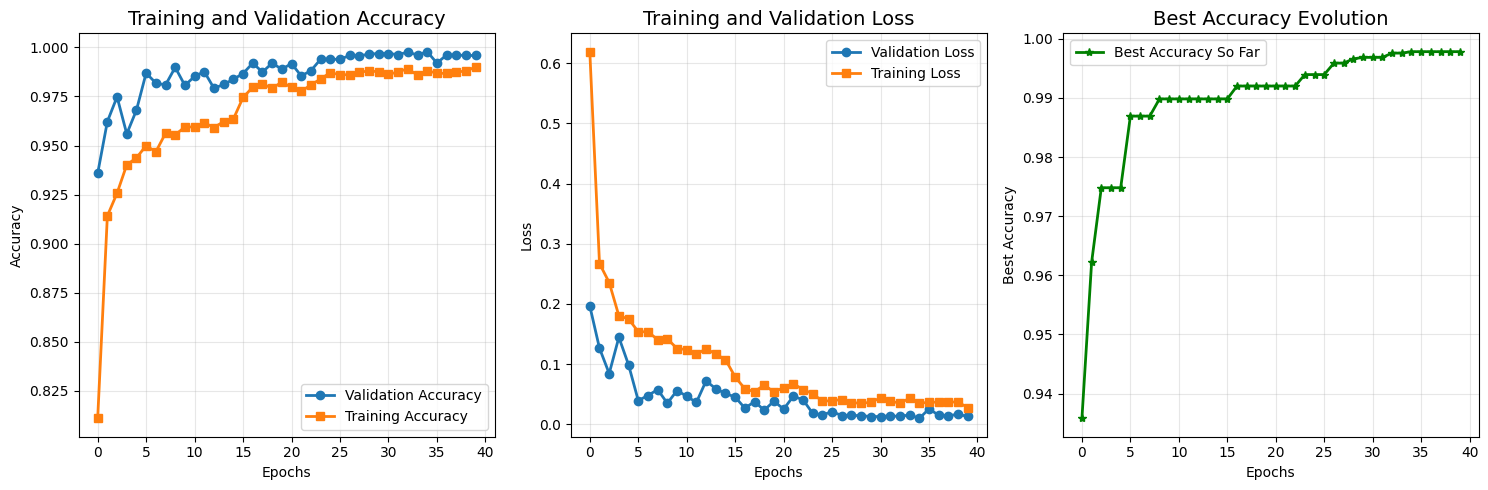

📈 Training Summary:
   Final Training Accuracy: 0.9901
   Final Validation Accuracy: 0.9959
   Best Validation Accuracy: 0.9978
   Final Training Loss: 0.0279
   Final Validation Loss: 0.0130


In [ ]:
# ===================================================================
# PLOT TRAINING RESULTS - OPTIMIZED
# ===================================================================
print("📊 Plotting training history...")
plot_history(history)

📂 Loading best model with metadata...
📊 Model Information:
   🏷️  Model: efficientnet_b3
   📈 Best Epoch: 35/40
   🎯 Best Accuracy: 0.9978
   📊 Train Accuracy: 0.9881
   📉 Validation Loss: 0.0098
   📈 Overfitting Gap: -0.0097
   🛡️  Overfitting Check: Enabled
   🔍 Overfitting Threshold: 0.05
   ⚙️  Learning Rate: 0.001
   📦 Batch Size: 50
   🖼️  Image Size: 224
   🏷️  Classes: 15
   🕐 Training Started: 2025-09-09 01:18:09
   💾 Model Saved: 2025-09-09 02:01:34
   🖥️  Device: cuda

🧪 Evaluating on test set...
📊 Model Information:
   🏷️  Model: efficientnet_b3
   📈 Best Epoch: 35/40
   🎯 Best Accuracy: 0.9978
   📊 Train Accuracy: 0.9881
   📉 Validation Loss: 0.0098
   📈 Overfitting Gap: -0.0097
   🛡️  Overfitting Check: Enabled
   🔍 Overfitting Threshold: 0.05
   ⚙️  Learning Rate: 0.001
   📦 Batch Size: 50
   🖼️  Image Size: 224
   🏷️  Classes: 15
   🕐 Training Started: 2025-09-09 01:18:09
   💾 Model Saved: 2025-09-09 02:01:34
   🖥️  Device: cuda

🧪 Evaluating on test set...


Testing:   0%|          | 0/83 [00:00<?, ?batch/s]


🎯 Final Test Accuracy: 0.9961
📊 Validation Accuracy: 0.9978
📈 Test vs Validation: -0.0017

           📊 BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      0.99      1.00       199
                     Pepper__bell___healthy       0.99      1.00      1.00       296
                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       0.99      0.99      0.99       200
                           Potato___healthy       1.00      0.97      0.98        30
                      Tomato_Bacterial_spot       1.00      1.00      1.00       426
                        Tomato_Early_blight       0.99      0.98      0.99       200
                         Tomato_Late_blight       0.98      1.00      0.99       382
                           Tomato_Leaf_Mold       1.00      0.99      1.00       191
  

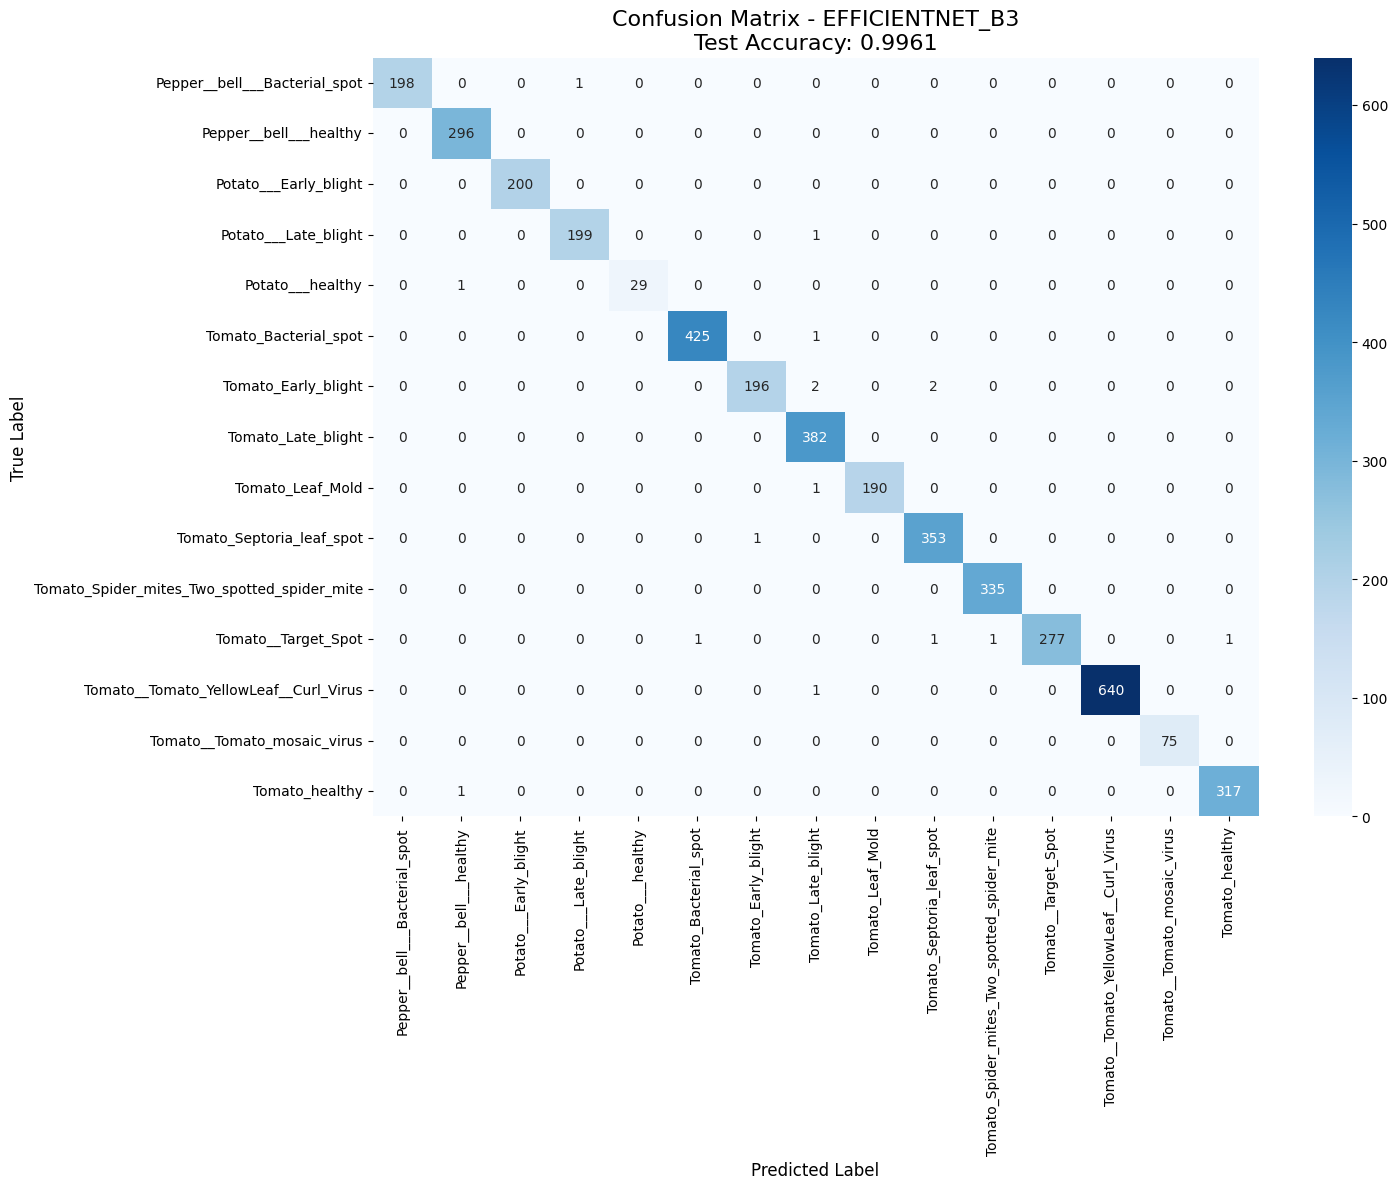

✅ Evaluation completed!


In [ ]:
# ===================================================================
# MODEL EVALUATION - OPTIMIZED
# ===================================================================
print("📂 Loading best model for evaluation...")

# Load the best model
if os.path.exists('best_efficientnet_model.pth'):
    checkpoint = torch.load('best_efficientnet_model.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"✅ Model loaded successfully!")
    print(f"   Best epoch: {checkpoint.get('best_epoch', 'Unknown')}")
    print(f"   Best val accuracy: {checkpoint.get('best_val_acc', 0):.2f}%")
    print(f"   Overfitting gap: {checkpoint.get('overfitting_gap', 0):+.2f}%")
    
    print(f"\n🧪 Evaluating on validation set...")
    
    # Quick evaluation
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            if batch_idx % 10 == 0:
                current_acc = 100 * correct / total
                print(f"\r🔄 Evaluating: {batch_idx+1}/{len(val_loader)} | Acc: {current_acc:.2f}%", end='')
    
    final_accuracy = 100 * correct / total
    print(f"\n🎯 Final Validation Accuracy: {final_accuracy:.2f}%")
    
    # Compare with stored best accuracy
    stored_acc = checkpoint.get('best_val_acc', 0)
    print(f"📊 Stored Best Accuracy: {stored_acc:.2f}%")
    print(f"📈 Difference: {final_accuracy - stored_acc:+.2f}%")
    
    print(f"\n✅ Evaluation completed successfully!")
    print(f"? Model ready for inference and testing")
    
else:
    print("❌ No trained model found. Please run training first.")

🔍 Model Information:
📊 Model Information:📊 Model Information:
   🏷️  Model: efficientnet_b3
   📈 Best Epoch: 35/40
   🎯 Best Accuracy: 0.9978
   📊 Train Accuracy: 0.9881
   📉 Validation Loss: 0.0098
   📈 Overfitting Gap: -0.0097
   🛡️  Overfitting Check: Enabled
   🔍 Overfitting Threshold: 0.05
   ⚙️  Learning Rate: 0.001
   📦 Batch Size: 50
   🖼️  Image Size: 224
   🏷️  Classes: 15
   🕐 Training Started: 2025-09-09 01:18:09
   💾 Model Saved: 2025-09-09 02:01:34
   🖥️  Device: cuda

🖼️ Making prediction...

   🏷️  Model: efficientnet_b3
   📈 Best Epoch: 35/40
   🎯 Best Accuracy: 0.9978
   📊 Train Accuracy: 0.9881
   📉 Validation Loss: 0.0098
   📈 Overfitting Gap: -0.0097
   🛡️  Overfitting Check: Enabled
   🔍 Overfitting Threshold: 0.05
   ⚙️  Learning Rate: 0.001
   📦 Batch Size: 50
   🖼️  Image Size: 224
   🏷️  Classes: 15
   🕐 Training Started: 2025-09-09 01:18:09
   💾 Model Saved: 2025-09-09 02:01:34
   🖥️  Device: cuda

🖼️ Making prediction...


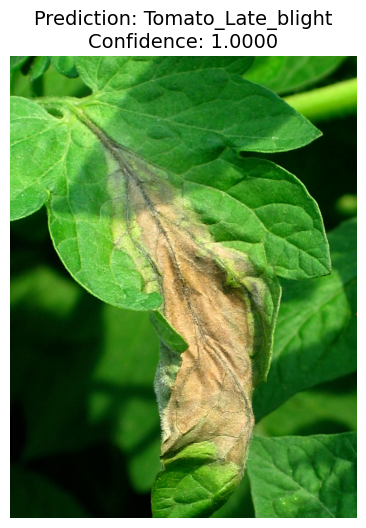

📸 Image: late_blight_tomato_leaf5x12001-1.jpg
🏷️  Predicted Class: Tomato_Late_blight
📊 Confidence: 1.0000

🏆 Top 3 Predictions:
   1. Tomato_Late_blight: 1.0000
   2. Pepper__bell___healthy: 0.0000
   3. Pepper__bell___Bacterial_spot: 0.0000

📁 Model saved in organized structure:
   📂 Directory: ./modelsCP/efficientnet-b3-lr0.001
   💾 Checkpoint: ./modelsCP/efficientnet-b3-lr0.001/best_result.pth
   🔄 Format: PyTorch checkpoint with full metadata

🏆 Top 3 Predictions:
   1. Tomato_Late_blight: 1.0000
   2. Pepper__bell___healthy: 0.0000
   3. Pepper__bell___Bacterial_spot: 0.0000

📁 Model saved in organized structure:
   📂 Directory: ./modelsCP/efficientnet-b3-lr0.001
   💾 Checkpoint: ./modelsCP/efficientnet-b3-lr0.001/best_result.pth
   🔄 Format: PyTorch checkpoint with full metadata


In [ ]:
# Example usage with model information
print("🔍 Model Information:")
checkpoint = load_model_info(MODEL_SAVE_PATH)

print(f"\n🖼️ Making prediction...")
image_path_to_predict = "./realImage/late_blight_tomato_leaf5x12001-1.jpg"
if os.path.exists(image_path_to_predict):
    predict_image(image_path_to_predict, model, class_names)
    
    # Show top 3 predictions
    model.eval()
    transform = data_transforms['val']
    image = Image.open(image_path_to_predict).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        top3_prob, top3_idx = torch.topk(probabilities, 3)
    
    print(f"\n🏆 Top 3 Predictions:")
    for i in range(3):
        idx = top3_idx[i].item()
        prob = top3_prob[i].item()
        print(f"   {i+1}. {class_names[idx]}: {prob:.4f}")
        
else:
    print(f"❌ Image not found at: {image_path_to_predict}")
    
# Additional model comparison info
print(f"\n📁 Model saved in organized structure:")
print(f"   📂 Directory: {MODEL_DIR}")
print(f"   💾 Checkpoint: {MODEL_SAVE_PATH}")
print(f"   🔄 Format: PyTorch checkpoint with full metadata")